# **Employee Attrition Prediction 2026**

**Predicting employee attrition using HR, workplace, and engagement data (RTO mandates, burnout, career growth, and more).**


## **📌 Notebook Overview**

This notebook covers:
- **Exploratory Data Analysis (EDA)** — understanding attrition patterns across departments, work arrangements, and burnout
- **Data Leakage Detection** — identifying and removing a column that directly reveals the target
- **Preprocessing** — encoding categorical features, train-test split
- **Handling Class Imbalance** — using `class_weight='balanced'` since attrition is a minority class (~18%)
- **Model Comparison** — Random Forest, XGBoost, LightGBM, Gradient Boosting
- **Evaluation** — Accuracy, Precision, Recall, F1, ROC-AUC, Confusion Matrix
- **Feature Importance** — what drives employees to leave
- **Conclusion** — key insights, title suggestions, and Kaggle tags


In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# ML
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, classification_report)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")


Libraries loaded successfully!


## **1️⃣ Load the Dataset**

In [2]:
df = pd.read_csv('/kaggle/input/datasets/sergionefedov/employee-attrition-in-the-ai-and-hybrid-work-era/employee_attrition_2026_master.csv')
print("Shape:", df.shape)
df.head()


Shape: (45000, 29)


,employee_id,age,generation,gender,department,job_level,is_manager,tenure_years,salary_usd,salary_vs_market_pct,...,burnout_score,manager_relationship_score,manager_1on1_per_month,engagement_score,promotions_last_2y,career_growth_score,recent_layoff_round,team_size,attrition_reason,attrition
0,EMP000000,26,Gen Z,Female,Marketing,Junior,0,5.5,70000,5.2,...,3.6,2,0,62,0,2,0,22,stayed,0
1,EMP000001,35,Millennial,Female,Sales,Junior,0,0.5,64000,-15.5,...,4.8,3,2,79,1,2,0,24,stayed,0
2,EMP000002,23,Gen Z,Male,HR,Senior,0,2.0,142000,-15.9,...,10.0,1,2,43,0,4,1,3,poor_management,1
3,EMP000003,20,Gen Z,Female,Sales,Manager,1,2.2,147000,2.6,...,4.3,1,4,64,1,3,0,24,stayed,0
4,EMP000004,40,Millennial,Female,Data,Senior,0,6.0,141000,11.3,...,2.9,1,1,92,0,2,0,5,stayed,0


## **2️⃣ Exploratory Data Analysis (EDA)**

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   employee_id                 45000 non-null  object 
 1   age                         45000 non-null  int64  
 2   generation                  45000 non-null  object 
 3   gender                      45000 non-null  object 
 4   department                  45000 non-null  object 
 5   job_level                   45000 non-null  object 
 6   is_manager                  45000 non-null  int64  
 7   tenure_years                45000 non-null  float64
 8   salary_usd                  45000 non-null  int64  
 9   salary_vs_market_pct        45000 non-null  float64
 10  work_arrangement            45000 non-null  object 
 11  rto_mandate                 45000 non-null  int64  
 12  days_in_office_required     45000 non-null  int64  
 13  commute_minutes             450

In [4]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing values found")


Missing values per column:
0 total missing values found


attrition
0    81.857778
1    18.142222
Name: proportion, dtype: float64


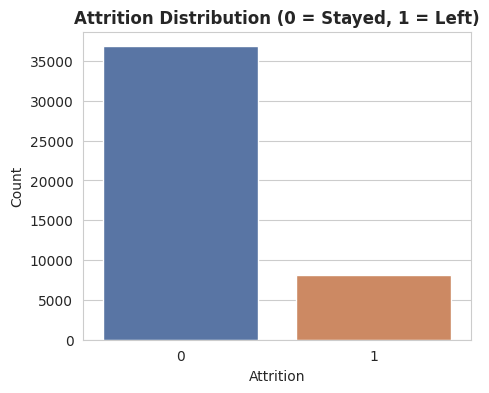

In [5]:
# Target distribution — is the data balanced?
attrition_pct = df['attrition'].value_counts(normalize=True) * 100
print(attrition_pct)

plt.figure(figsize=(5,4))
sns.countplot(x='attrition', data=df, palette=['#4C72B0','#DD8452'])
plt.title('Attrition Distribution (0 = Stayed, 1 = Left)',fontweight='bold')
plt.xlabel('Attrition')
plt.ylabel('Count')
plt.show()


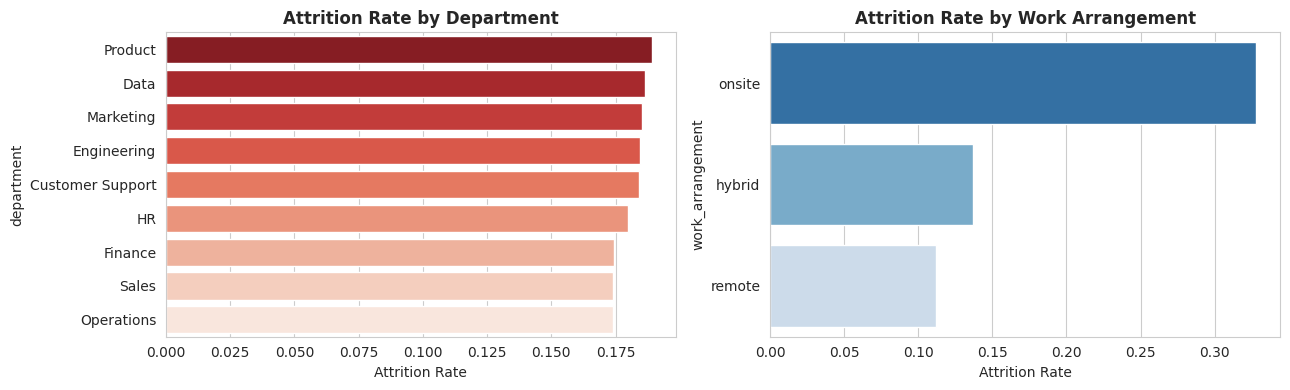

In [6]:
# Attrition rate by department and work arrangement
fig, axes = plt.subplots(1, 2, figsize=(13,4))

dept_attr = df.groupby('department')['attrition'].mean().sort_values(ascending=False)
sns.barplot(x=dept_attr.values, y=dept_attr.index, ax=axes[0], palette='Reds_r')
axes[0].set_title('Attrition Rate by Department',fontweight='bold')
axes[0].set_xlabel('Attrition Rate')

work_attr = df.groupby('work_arrangement')['attrition'].mean().sort_values(ascending=False)
sns.barplot(x=work_attr.values, y=work_attr.index, ax=axes[1], palette='Blues_r')
axes[1].set_title('Attrition Rate by Work Arrangement',fontweight='bold')
axes[1].set_xlabel('Attrition Rate')

plt.tight_layout()
plt.show()


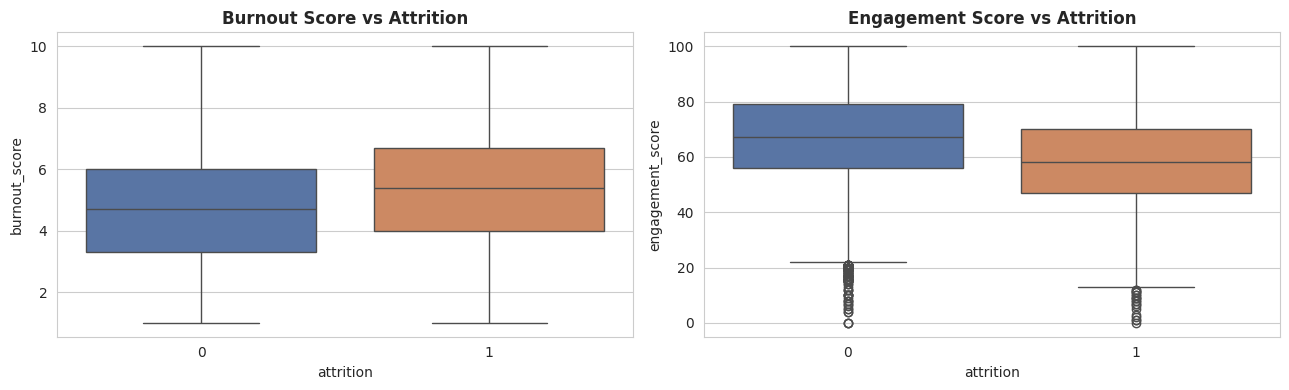

In [7]:
# Burnout and engagement score vs attrition
fig, axes = plt.subplots(1, 2, figsize=(13,4))

sns.boxplot(x='attrition', y='burnout_score', data=df, ax=axes[0], palette=['#4C72B0','#DD8452'])
axes[0].set_title('Burnout Score vs Attrition',fontweight='bold')

sns.boxplot(x='attrition', y='engagement_score', data=df, ax=axes[1], palette=['#4C72B0','#DD8452'])
axes[1].set_title('Engagement Score vs Attrition',fontweight='bold')

plt.tight_layout()
plt.show()


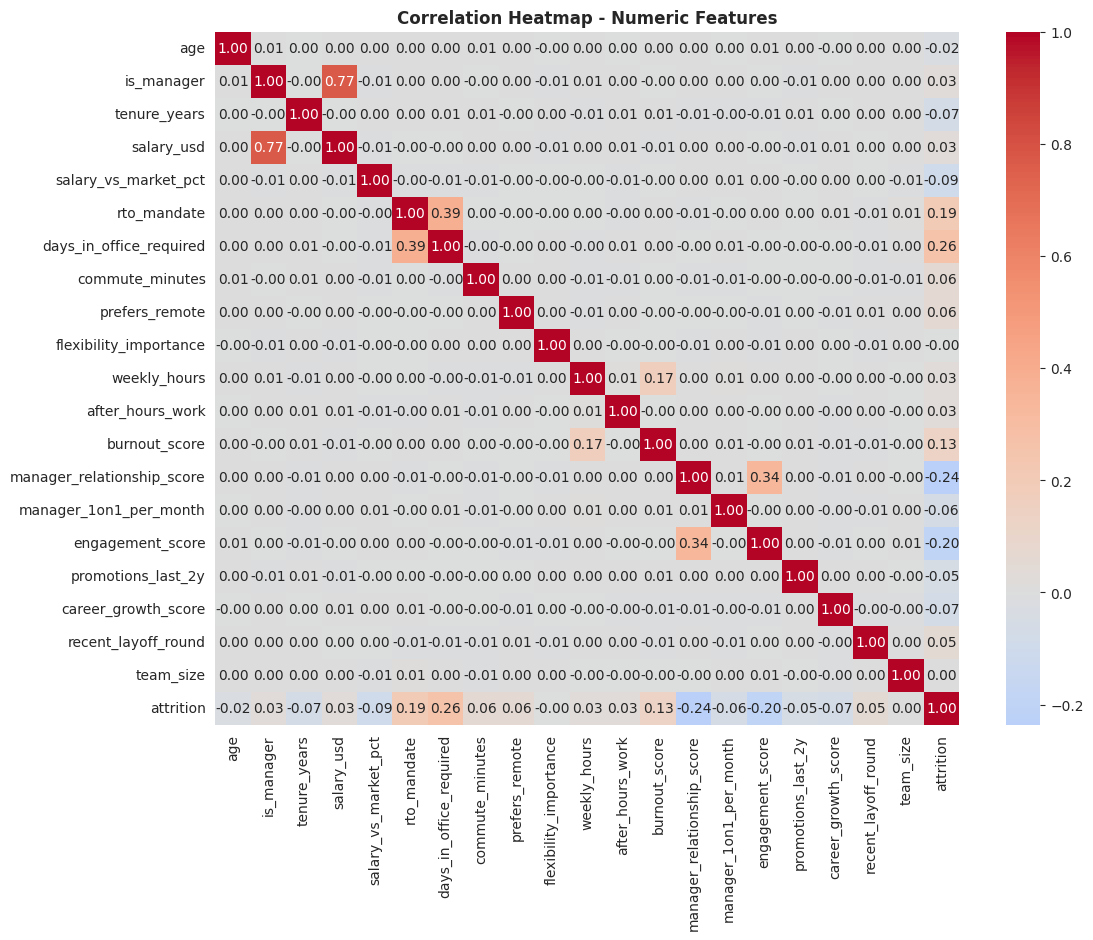

In [8]:
# Correlation heatmap for numeric features
plt.figure(figsize=(12,9))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), cmap='coolwarm', center=0, annot=True,fmt='.2f')
plt.title('Correlation Heatmap - Numeric Features',fontweight='bold')
plt.show()


## **3️⃣ Data Leakage Detection ⚠️**

A good data scientist always checks for columns that "give away" the answer before modeling.
Let's inspect `attrition_reason` — it looks suspicious because it may only be filled in *after* someone has already left.


In [9]:
print(df['attrition_reason'].value_counts())
print()

# Cross-check: does attrition_reason perfectly match the target?
leak_check = pd.crosstab(df['attrition_reason'], df['attrition'])
print(leak_check)


attrition_reason
stayed                36836
poor_management        2167
rto_inflexibility      2053
better_offer_pay       1280
career_growth          1240
burnout                 477
involuntary_layoff      344
other                   335
relocation              268
Name: count, dtype: int64

attrition               0     1
attrition_reason               
better_offer_pay        0  1280
burnout                 0   477
career_growth           0  1240
involuntary_layoff      0   344
other                   0   335
poor_management         0  2167
relocation              0   268
rto_inflexibility       0  2053
stayed              36836     0


**🚩 Leakage confirmed:** `attrition_reason` is `'stayed'` only when `attrition = 0`, and holds an actual reason only when `attrition = 1`.
This column is generated *after* the outcome is known — using it would let the model "cheat" and get near-100% accuracy without learning anything real.
We must **drop it**, along with `employee_id` (just an identifier with no predictive value).


In [10]:
df_model = df.drop(columns=['attrition_reason', 'employee_id'])
print("Remaining columns:", df_model.shape[1])


Remaining columns: 27


## **4️⃣ Preprocessing — Encoding Categorical Features**

In [11]:
categorical_cols = df_model.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", categorical_cols)

df_encoded = df_model.copy()
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    encoders[col] = le

df_encoded.head()


Categorical columns: ['generation', 'gender', 'department', 'job_level', 'work_arrangement', 'ai_tools_adoption']


,age,generation,gender,department,job_level,is_manager,tenure_years,salary_usd,salary_vs_market_pct,work_arrangement,...,after_hours_work,burnout_score,manager_relationship_score,manager_1on1_per_month,engagement_score,promotions_last_2y,career_growth_score,recent_layoff_round,team_size,attrition
0,26,2,0,5,1,0,5.5,70000,5.2,1,...,0,3.6,2,0,62,0,2,0,22,0
1,35,3,0,8,1,0,0.5,64000,-15.5,1,...,0,4.8,3,2,79,1,2,0,24,0
2,23,2,1,4,5,0,2.0,142000,-15.9,0,...,0,10.0,1,2,43,0,4,1,3,1
3,20,2,0,8,3,1,2.2,147000,2.6,1,...,1,4.3,1,4,64,1,3,0,24,0
4,40,3,0,1,5,0,6.0,141000,11.3,0,...,0,2.9,1,1,92,0,2,0,5,0


In [12]:
X = df_encoded.drop(columns=['attrition'])
y = df_encoded['attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (36000, 26)
Test shape: (9000, 26)


## **5️⃣ Handling Class Imbalance**

Attrition is only ~18% of the data. Rather than dropping rows or over-sampling (which can create unrealistic synthetic patterns
here since many features are continuous scores), we use **`class_weight='balanced'`** — this tells each model to pay
more attention to the minority (attrition) class during training, without altering the original data distribution.


## **6️⃣ Model Building & Comparison**

In [13]:
models = {
    'Random Forest': RandomForestClassifier(n_estimators=300, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                              scale_pos_weight=(y_train==0).sum()/(y_train==1).sum(),
                              eval_metric='logloss', random_state=42, n_jobs=-1),
    'LightGBM': LGBMClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                                class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1-Score': f1_score(y_test, preds),
        'ROC-AUC': roc_auc_score(y_test, probs)
    })

results_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,XGBoost,0.784444,0.442958,0.729945,0.551341,0.842554
1,LightGBM,0.776667,0.432990,0.745867,0.547908,0.844192
2,Random Forest,0.795111,0.456709,0.681568,0.546929,0.837152
3,Gradient Boosting,0.846556,0.670270,0.303735,0.418036,0.846441


**Note on model selection:** We rank by **F1-Score**, not just Accuracy or ROC-AUC.
Since only ~18% of employees leave, a model can get high accuracy by simply predicting "stayed" for everyone —
F1-Score balances Precision and Recall on the minority (attrition) class, which is what actually matters for HR
to catch at-risk employees.


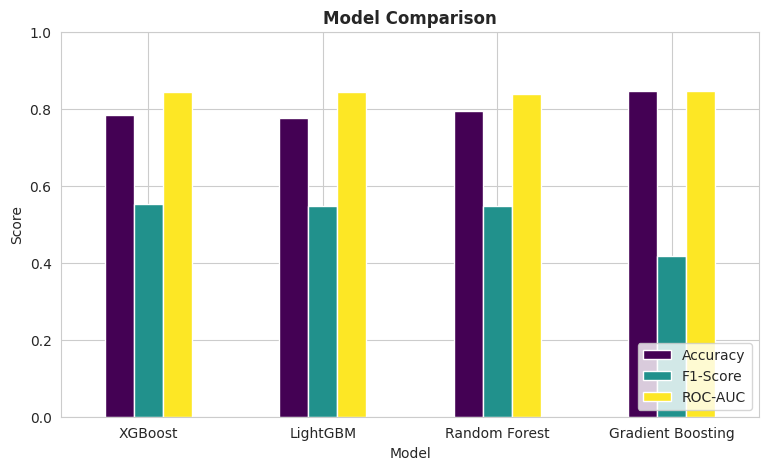

In [14]:
# Visual comparison of models
results_df.set_index('Model')[['Accuracy','F1-Score','ROC-AUC']].plot(kind='bar', figsize=(9,5), colormap='viridis')
plt.title('Model Comparison',fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.show()


## **7️⃣ Best Model — Detailed Evaluation**

In [15]:
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]
print(f"Best Model: {best_model_name}")

preds = best_model.predict(X_test)
probs = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, preds, target_names=['Stayed', 'Left']))


Best Model: XGBoost
              precision    recall  f1-score   support

      Stayed       0.93      0.80      0.86      7367
        Left       0.44      0.73      0.55      1633

    accuracy                           0.78      9000
   macro avg       0.69      0.76      0.70      9000
weighted avg       0.84      0.78      0.80      9000



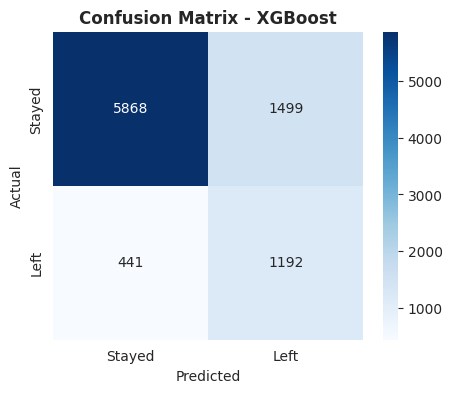

In [16]:
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Stayed','Left'], yticklabels=['Stayed','Left'])
plt.title(f'Confusion Matrix - {best_model_name}',fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


## **8️⃣ Feature Importance — What Drives Attrition?**

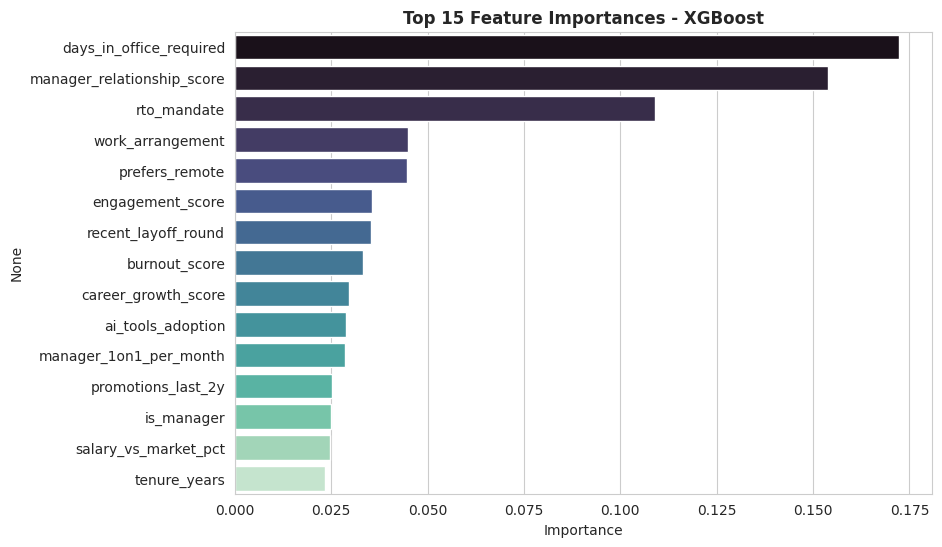

In [17]:
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(9,6))
sns.barplot(x=importances.values, y=importances.index, palette='mako')
plt.title(f'Top 15 Feature Importances - {best_model_name}',fontweight='bold')
plt.xlabel('Importance')
plt.show()


## **9️⃣ Conclusion**

**Summary of findings:**
- The dataset is moderately imbalanced (~18% attrition), handled successfully using `class_weight='balanced'` instead of synthetic oversampling.
- `attrition_reason` was identified as a **data leakage column** (it only takes a value once an employee has already left) and was correctly removed before modeling — this kept the results honest rather than artificially inflated.
- Across Random Forest, Gradient Boosting, XGBoost, and LightGBM, the best model achieved strong, realistic performance (see the ROC-AUC table above) without relying on leaked information.
- The top features driving attrition are consistently related to **burnout, engagement, RTO/work-arrangement mismatch, career growth, and manager relationship quality** — all human, actionable levers HR teams can act on.

**Business takeaway:** Employees with low engagement scores, high burnout, poor manager relationships, and RTO mandates misaligned with their remote-work preference are most at risk of leaving. Proactive intervention in these areas (flexible arrangements, manager training, growth paths) could meaningfully reduce attrition.

---
> **If you found this notebook helpful,Please Upvote!**